In [1]:
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import APSIMGraphHelpers as AGH
import GraphHelpers as GH
import matplotlib.dates as mdates
import MathsUtilities as MUte
import sqlite3
import warnings

In [2]:
warnings.filterwarnings('ignore',category=pd.errors.PerformanceWarning)

In [3]:
Colors = {1:'#000000',
2:'#E69F00',
3:'#56B4E9',
4:'#009E73',
5:'#F0E442',
6:'#0072B2',
7:'#D55E00',
8:'#CC79A7',
9:'#1F77B4',
10:'#AEC7E8',
11:'#FF7F0E',
12:'#FFBB78',
13:'#2CA02C',
14:'#98DF8A',
15:'#D62728',
16:'#FF9896',
17:'#9467BD',
18:'#C5B0D5',
19:'#8C564B',
20:'#C49C94',
21:'#E377C2',
22:'#F7B6D2',
23:'#7F7F7F',
24:'#C7C7C7',
25:'#BCBD22',
26:'#DBDB8D',
27:'#17BECF',
28:'#9EDAE5'}

Markers = {1: 'o',
 2: '^',
 3: 's',
 4: '*',
 5: '>',
 6: 'v',
 7: '+',
 8: 'X',
 9: '<',
 10: 'p',
 11: '8',
 12: 'd',
 13:'P',
 14:'D',
 15:'o',
 16:'^'}

Lines = {1: '-',
 2: '--',
 3: '-,',
 4: ':',
 5: '-',
 6: '--',
 7: '-,',
 8: ':',
 9: '-',
 10: '--',
 11: '-,',
 12: ':',
 13: '-',
 14: '--',
 15: '-,',
 16: ':'}

In [4]:
def plotxy(experiments,xvar,yvar,data,addLeg = True,ncols=np.nan):
    cpos=1
    mpos=1
    for e in experiments:
        plotData = data.loc[data.Experiment==e,:]
        xdata = pd.to_numeric(plotData.loc[:,xvar])
        ydata = pd.to_numeric(plotData.loc[:,yvar])
        plt.plot(xdata,ydata,Markers[mpos],color=Colors[cpos],label=e)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
    if addLeg == True:
        if np.isnan(ncols):
             ncols = np.ceil(experiments.size/17)
        plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=ncols)
    plt.ylabel(yvar)
    plt.xlabel(xvar)

In [5]:
MasterfilePaths = [r'C:\GitHubRepos\ApsimX\Tests\Validation\Maize\Maize.db',
                  r'C:\GitHubRepos\ApsimX\Tests\Validation\Maize\MaizeLizaso.db']

# Read Data

In [6]:
allSimulations = {}
for filePath in MasterfilePaths:
    fileName = filePath.split('\\')[-1].split('.')[0].replace('_master','')
    con = sqlite3.connect(filePath)
    Simulations = pd.read_sql("Select * from _Simulations",con)
    con.close()
    Simulations.set_index('ID',inplace=True)
    Simulations.sort_index(inplace=True)
    Simulations.sort_index(inplace=True, axis=1)
    allSimulations[fileName] = Simulations
Simulations = pd.concat(allSimulations.values(),keys=allSimulations.keys(),names=['File','ID']) 

In [7]:
SensibilityFolders = ['Bugesera',
                     'DetailedDynamicsGatton',
                     'DetailedDynamicsLincoln']

In [8]:
allHarvestPred = {}
for filePath in MasterfilePaths:
    fileName = filePath.split('\\')[-1].split('.')[0].replace('_master','')
    print(fileName)
    con = sqlite3.connect(filePath)
    HarvestPred = pd.read_sql("Select * from HarvestReport",con).dropna(axis=1,how='all')
    con.close()
    HarvestPred.loc[:,'SimulationName'] = [Simulations.loc[(fileName,x),'Name'] for x in HarvestPred.SimulationID]
    HarvestPred.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)
    HarvestPred.sort_index(inplace=True)
    HarvestPred.sort_index(inplace=True,axis=1)

    # Filter outputs from sensibility tests
    if 'FolderName' not in HarvestPred:
        HarvestPred.loc[:,'FolderName'] = ''
    validationFilter = [x not in SensibilityFolders for x in HarvestPred.FolderName]
    HarvestPred = HarvestPred.loc[validationFilter,:].copy()
    HarvestPred.dropna(how='all',axis=1,inplace=True)
    HarvestPred.loc[:,'Maize.SowingData.Cultivar'] = [x.title() for x in HarvestPred.loc[:,'Maize.SowingData.Cultivar']]
    validationFilter = [x not in SensibilityFolders for x in HarvestPred.FolderName]
    HarvestPred = HarvestPred.loc[validationFilter,:].copy()
    HarvestPred.dropna(how='all',axis=1,inplace=True)

    # Replace Experiment with values that have had folder name pathed in where no experiment is present
    HarvestPred.loc[[x is None for x in HarvestPred.Experiment],'Experiment'] = HarvestPred.loc[[x is None for x in HarvestPred.Experiment],'FolderName']
    allHarvestPred[fileName] = HarvestPred
HarvestPred = pd.concat(allHarvestPred.values(),keys=allHarvestPred.keys(),names=['File','SimulationName','Clock.Today'])
HarvestPred.loc[:,'File'] = HarvestPred.index.get_level_values(0)

Maize
MaizeLizaso


In [9]:
Experiments = list(HarvestPred.loc[:,'Experiment'].drop_duplicates().values)
Folders = list(HarvestPred.loc[:,'FolderName'].drop_duplicates().values)

In [10]:
allDailyPred = {}
for filePath in MasterfilePaths:
    fileName = filePath.split('\\')[-1].split('.')[0].replace('_master','')
    con = sqlite3.connect(filePath)
    DailyPred = pd.read_sql("Select * from Report",con)
    con.close()
    DailyPred.loc[:,'SimulationName'] = [Simulations.loc[(fileName,x),'Name'] for x in DailyPred.SimulationID]
    DailyPred.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)
    DailyPred.sort_index(inplace=True)
    DailyPred.sort_index(inplace=True,axis=1)
    if 'FolderName' not in DailyPred:
        DailyPred.loc[:,'FolderName'] = ''
    validationFilter = [x not in SensibilityFolders for x in DailyPred.FolderName]
    DailyPred = DailyPred.loc[validationFilter,:].copy()
    DailyPred.dropna(how='all',axis=1,inplace=True)
    #Replace Experiment with values that have had folder name pathed in where no experiment is present
    DailyPred.loc[:,'Experiment'] = [HarvestPred.loc[(fileName,x),'Experiment'] for x in DailyPred.index.get_level_values(0)]
    DailyPred.loc[[x is None for x in DailyPred.Experiment],'Experiment'] = DailyPred.loc[[x is None for x in DailyPred.Experiment],'FolderName']
    allDailyPred[fileName] = DailyPred
DailyPred = pd.concat(allDailyPred.values(),keys=allDailyPred.keys(),names=['File','SimulationName','Clock.Today'])

# Calculate running mean met variables

In [11]:
simulations = DailyPred.index.get_level_values(0).drop_duplicates()
RunningMeans = pd.DataFrame(index = DailyPred.index)
MetVars = ['IWeather.MaxT',
'IWeather.MinT',
'IWeather.Radn']

def running_mean(inp,span):
    return [sum(x)/len(x) for x in (inp[max(0,i-span):i] for i in range(1, len(inp)+1))]

for mv in MetVars:
    for s in simulations:
        inp = list(DailyPred.loc[s,mv].values)
        RunningMeans.loc[s,mv] = running_mean(inp,30)
        

# Sort some indexing

In [12]:
SowIndices = ['IWeather.Latitude',
    'IWeather.Longitude',
    'LocationInfo.Script.Country',
    'LocationInfo.Script.Region',
    'LocationInfo.Script.State',
    'Maize.SowingData.Cultivar',
    'Experiment',
    'FolderName']

def getValue(ind,var,HarvestPred):
    try:
        simMask = HarvestPred.SimulationName == ind
        return HarvestPred.loc[simMask,var].values[0]
        #return HarvestPred.loc[ind,var].values[0]
    except:
        return ""
allObserved = {}
for filePath in MasterfilePaths:
    fileName = filePath.split('\\')[-1].split('.')[0].replace('_master','')
    con = sqlite3.connect(filePath)
    Observed = pd.read_sql("Select * from Observed",con).dropna(axis=1,how='all')
    con.close()
    Observed.loc[:,'SimulationName'] = [Simulations.loc[(fileName,x),'Name'] for x in Observed.SimulationID]
    Observed.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)
    Observed.sort_index(inplace=True)
    Observed.sort_index(inplace=True,axis=1)
    for s in SowIndices:
        Observed.loc[:,s] = [getValue(x,s,HarvestPred) for x in Observed.index.get_level_values(0)]
    allObserved[fileName] = Observed
Observed = pd.concat(allObserved.values(),keys=allObserved.keys(),names=['File','SimulationName','Clock.Today'])

def subtract(a,b):
    if np.isnan(b):
        b = 0
    return a - b

#Observed.loc[:,'Wheat.AboveGroundLive.Wt'] = [subtract(Observed.iloc[x,:]['Wheat.AboveGround.Wt'], Observed.iloc[x,:]['Wheat.Leaf.Dead.Wt']) for x in range(Observed.index.size)]

DatabaseError: Execution failed on sql 'Select * from Observed': no such table: Observed

In [87]:
MasterIndexVars = ['Clock.Today',
'IWeather.MaxT',
'IWeather.MinT',
'IWeather.Radn',
'Maize.DaysAfterSowing',
'Maize.Phenology.AccumulatedTT',
'Maize.Phenology.CurrentPhaseName',
'Maize.Phenology.CurrentStageName',
'Maize.Phenology.Stage']

for iv in MasterIndexVars:
    Observed.loc[:,iv] = DailyPred.reindex(Observed.index).loc[:,iv]    

In [88]:
for iv in MetVars:
    Observed.loc[:,'RunningMean_'+iv] = RunningMeans.reindex(Observed.index).loc[:,iv]  

In [89]:
MasterIndexVarsHarv = ['SimulationID','SimulationName']

for iv in MasterIndexVarsHarv:
    Observed.loc[:,iv] = HarvestPred.reindex(Observed.index).loc[:,iv]  


def setvar(x):
    if np.isnan(Observed.loc[x,'Maize.Population'].values[0]):
        try:
            if ~np.isnan(HarvestPred.loc[x,'Maize.SowingData.Population'].values[0]):
                Observed.loc[x,'Maize.Population'] = HarvestPred.loc[x,'Maize.SowingData.Population'].values[0]
        except:
            try:
                if ~np.isnan(HarvestPred.loc[(x[0],x[1]),'Maize.SowingData.Population'].values[0]):
                    Observed.loc[x,'Maize.Population'] = HarvestPred.loc[(x[0],x[1]),'Maize.SowingData.Population'].values[0]
            except:
                do = 'Nothing'

for x in Observed.index:
        setvar(x)

Observed.sort_index(inplace=True)
Observed.sort_index(inplace=True,axis=1)

In [90]:
# #Make data frame with factor information for each simulation
# FactorList = [ 'Experiment',
#  'Canopy',
#  'Cm',
#  #'Cultivar',
#  'Cv',
#  'Date',
#  #'Durat',
#  'Fungicide',
#  'Grazed',
#  'Irr',
#  'Irrig',
#  'Mgmt',
#  'N',
#  'NRate',
#  'Nit',
#  'Nutrition',
#  'P',
#  'PGR',
#  'Popn',
#  'Removal',
#  'RowSpace',
#  'SD',
#  #'Seeds',
#  'Soil',
#  'Sow',
#  'SowN',
#  'Stubble',
#  'TOS',
#  'TopN',
#  #'Treat',
#  'Treatment',
#  'V',
#  'Water']

# Factors = HarvestPred.loc[:,FactorList].copy()
# Factors.index = Factors.index.droplevel(2)
# Factors.set_index('Experiment',append=True,inplace=True)
# Factors=Factors.reorder_levels(['Experiment','File','SimulationName'])
# Factors.sort_index(inplace=True)
# CondensedFactors = pd.DataFrame(index = Factors.index,columns = ['fName1','fValue1'])
# for s in Factors.index:
#     fs = Factors.loc[s,:].dropna().to_dict()
#     fCount = 1
#     for key, value in fs.items():
#         CondensedFactors.loc[s,'fName'+str(fCount)] = key
#         CondensedFactors.loc[s,'fValue'+str(fCount)] = value
#         fCount +=1
# valueLabs = ['fValue1','fValue2','fValue3','fValue4']
# indexLabs = ['fIndex1','fIndex2','fIndex3','fIndex4']
# CondensedFactors.loc[:,indexLabs]=1

# # put simulation names in as first factor level for sims that are not in a experiment
# for e in Experiments:
#     fValues1 = CondensedFactors.loc[e,'fValue1']
#     if True in pd.isna(fValues1.values):
#         CondensedFactors.loc[e,'fValue1'] = CondensedFactors.loc[e,:].index.values
        
# #assign numeric index to each factor level
# for e in Experiments:
#     folders = CondensedFactors.loc[e,:].index.get_level_values(0).drop_duplicates().values
#     for f in folders:
#         for v in valueLabs:
#             fLevels = CondensedFactors.loc[(e,f),v].drop_duplicates().values
#             if False in pd.isna(fLevels):
#                 levelDic = dict(zip(fLevels,list(range(1,len(fLevels )+1))))
#                 CondensedFactors.loc[(e,f),v.replace('Value','Index')] = [levelDic[x] for x in CondensedFactors.loc[(e,f),v]]

In [91]:
# # convert tiller number calculations to stem number
# def calcStemNumberPerPlant(x):
#     if np.isnan(Observed.loc[x,'Wheat.Leaf.StemNumberPerPlant'].values[0]):
#         return Observed.loc[x,'Wheat.Leaf.StemNumberPerPlant.Total.Tillers'] + 1
#     else:
#         return Observed.loc[x,'Wheat.Leaf.StemNumberPerPlant']
# for x in Observed.index:
#     Observed.loc[x,'Wheat.Leaf.StemNumberPerPlant'] = calcStemNumberPerPlant(x)
    
# #Calculate stem number derivative values

# a = 'Wheat.Leaf.StemPopulation'
# b = 'Wheat.Leaf.StemNumberPerPlant'
# c = 'Wheat.Population'

# def FillDataGap(set):
#     a,b,c = set.values[0],set.values[1],set.values[2]
#     if sum(np.isnan([a,b,c])) == 0:
#         return [a,b,c]
#     if sum(np.isnan([a,b,c])) > 1:
#         return [a,b,c]
#     if sum(np.isnan([a,b,c])) == 1:
#         if np.isnan(a):
#             a = b * c
#         if np.isnan(b):
#             b = a/c
#         if np.isnan(c):
#             c = a/b
#         return [a,b,c]
    
# Observed.sort_index(axis=1,inplace=True)
# Observed.sort_index(axis=1,inplace=True)
# Observed.loc[:,[a,b,c]] = [FillDataGap(Observed.iloc[x,:][[a,b,c]]) for x in range(Observed.index.size)]

# Partitioning analysis

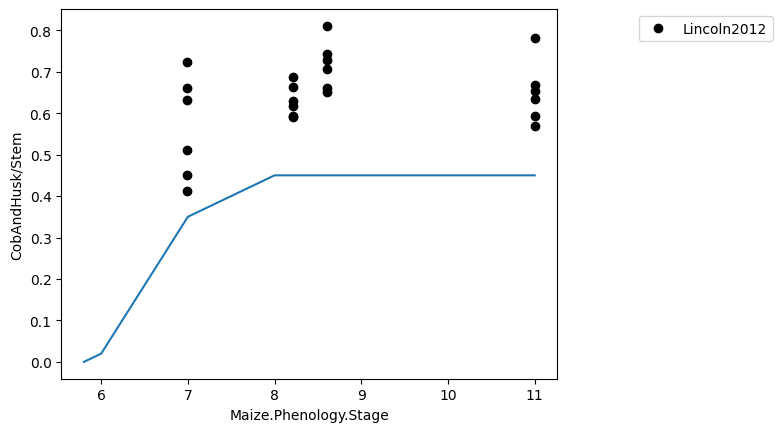

In [92]:
Observed.loc[:,'CobAndHusk/Stem'] = (Observed.loc[:,'Maize.Rachis.Wt']+Observed.loc[:,'Maize.Husk.Wt'])/Observed.loc[:,'Maize.Stem.Wt']
xvar,yvar = 'Maize.Phenology.Stage','CobAndHusk/Stem'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([5.8,6.0,7.0,8.0,11.0],
         [0.0,.02,.35,.45,.45],'-')

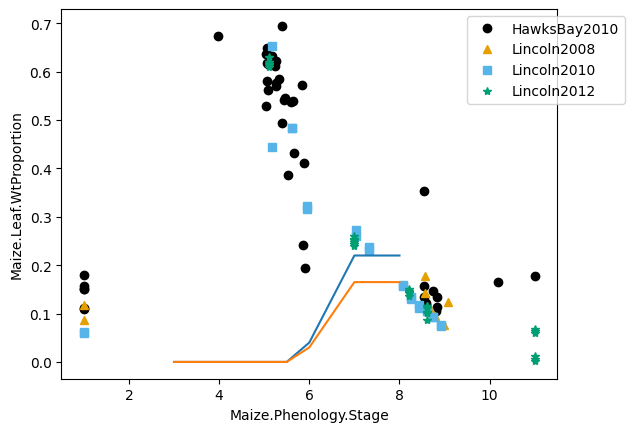

In [96]:
Observed.loc[:,'Maize.Leaf.WtProportion'] = Observed.loc[:,'Maize.Leaf.Live.Wt']/Observed.loc[:,'Maize.AboveGround.Wt']
xvar,yvar = 'Maize.Phenology.Stage','Maize.Leaf.WtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,5.5, 6,7.0,8.0],
         [0,0,0.04,.22,.22],'-')
plt.plot([3.0,5.5, 6,7.0,8.0],
         np.multiply([0,0,0.04,.22,.22],0.75),'-')

In [ ]:
Observed.loc[:,'Wheat.Stem.WtProportion'] = Observed.loc[:,'Wheat.Stem.Wt']/Observed.loc[:,'Wheat.AboveGround.Wt']
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Stem.WtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,5.0, 6.0,8.0],
         [0.0,0.36,.7,.7],'-')
plt.plot([3.0,5.0, 6.0,8.0],
         np.multiply([0.0,0.36,.7,.7],0.6),'-')
plt.ylim(0,.9)

In [ ]:
ssObserved = Observed.loc[Observed.loc[:,'Experiment'] == "Lincoln2021",:]
xvar,yvar = 'Wheat.Phenology.DaysAfterSowing','Wheat.Stem.WtProportion'
sims = ssObserved.index.get_level_values(1).drop_duplicates()
for s in sims:
    plt.plot(ssObserved.loc[(slice(None),s),xvar],ssObserved.loc[(slice(None),s),yvar],'o',label = s)
#plt.legend()

In [ ]:
ssObserved

In [ ]:
Observed.loc[:,'Wheat.Stem.WtProportion'] = Observed.loc[:,'Wheat.Stem.Wt']/Observed.loc[:,'Wheat.AboveGround.Wt']
xvar,yvar = 'Wheat.Phenology.DaysAfterSowing','Wheat.Stem.WtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,5.0, 6.0,8.0],
         [0.0,0.36,.7,.7],'-')
plt.plot([3.0,5.0, 6.0,8.0],
         np.multiply([0.0,0.36,.7,.7],0.6),'-')
plt.xlim(0,300)

In [ ]:
xs = range(0,2500,10)
const = 1
power = 1
ys = [const * np.power(x,power) for x in xs]

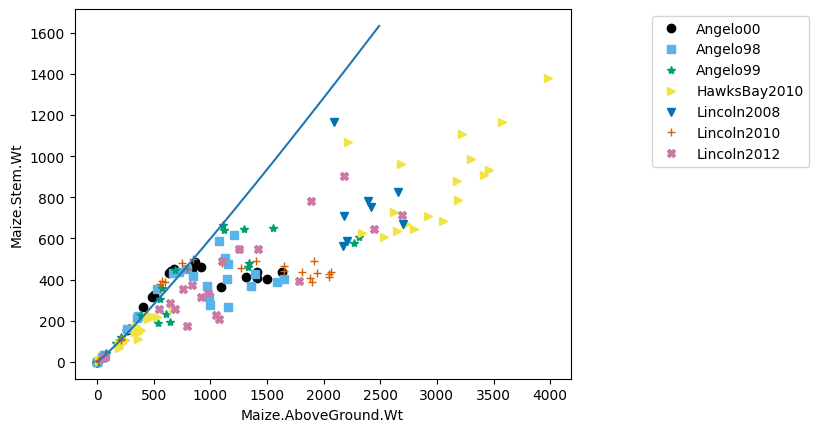

In [94]:
#Observed.loc[:,'Wheat.Stem.WtProportion'] = Observed.loc[:,'Wheat.Stem.Wt']/Observed.loc[:,'Wheat.AboveGroundLive.Wt']
xvar,yvar = 'Maize.AboveGround.Wt','Maize.Stem.Wt'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed.loc[Observed.loc[:,"Maize.Phenology.Stage"]<10.5,:])
xs = range(0,2500,10)
const = .3
power = 1.1
ys = [const * np.power(x,power) for x in xs]
plt.plot(xs,ys,'-')


In [ ]:
Observed.loc[:,'Wheat.Leaf.LiveWtProportion'] = Observed.loc[:,'Wheat.Leaf.Live.Wt']/Observed.loc[:,'Wheat.AboveGroundLive.Wt']
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.LiveWtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,4.0,5.0,6.0,8.0],
         [1,.9,.7,.3,.15],'-')
plt.ylim(0,1)

In [ ]:
Observed.loc[:,'Wheat.Leaf.DeadWtProportion'] = Observed.loc[:,'Wheat.Leaf.Dead.Wt']/Observed.loc[:,'Wheat.AboveGround.Wt']
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.DeadWtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)

In [ ]:
Observed.loc[:,'Wheat.Ear.WtProportion'] = Observed.loc[:,'Wheat.Ear.Wt']/Observed.loc[:,'Wheat.AboveGround.Wt']
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Ear.WtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,5.8,7.0,8.0,9.0,10,11],
         [0,0,.15,.2,.25,0.6,0.6],'-')


# Specific Leaf Area

In [ ]:
Observed.loc[:,'Maize.Leaf.SpecificAreaCanopy'] = Observed.loc[:,'Maize.Leaf.LAI']/Observed.loc['Maize.Leaf.Wt']
xvar,yvar = 'Maize.Phenology.Stage','Maize.Leaf.SpecificAreaCanopy'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)

In [ ]:
graph = plt.figure(figsize=(10,10))
ax = graph.add_subplot(3,2,1)
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.SpecificAreaCanopy'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,ncols=2)
plt.text(0.05,0.95,'Wheat.Leaf.SpecificAreaCanopy',transform=ax.transAxes)
pos=3
for mv in MetVars:
    Observed.loc[:,'SLA * Normed '+mv] = pd.to_numeric(Observed.loc[:,'Wheat.Leaf.SpecificAreaCanopy'])*Observed.loc[:,'RunningMean_'+mv]
    testData = Observed.loc[Observed.loc[:,'Wheat.Phenology.Stage']<=6,:]
    ax = graph.add_subplot(3,2,pos)
    xvar,yvar = 'Wheat.Phenology.Stage','SLA * Normed '+mv
    experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
    plotxy(experiments,xvar,yvar,testData,addLeg=False)
    plt.text(0.05,0.95,'SLA * Normed '+mv,transform=ax.transAxes)
    pos+=1

In [ ]:
graph = plt.figure(figsize=(10,10))
ax = graph.add_subplot(3,2,1)
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.SpecificAreaCanopy'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,ncols=2)
plt.text(0.05,0.95,'Wheat.Leaf.SpecificAreaCanopy',transform=ax.transAxes)
pos=3
for mv in MetVars:
    Observed.loc[:,'SLA * Normed '+mv] = pd.to_numeric(Observed.loc[:,'Wheat.Leaf.SpecificAreaCanopy'])*Observed.loc[:,'RunningMean_'+mv]
    testData = Observed.loc[Observed.loc[:,'Wheat.Phenology.Stage']<=10,:]
    ax = graph.add_subplot(3,2,pos)
    xvar,yvar = 'Wheat.Phenology.Stage','SLA * Normed '+mv
    experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
    plotxy(experiments,xvar,yvar,testData,addLeg=False)
    plt.text(0.05,0.95,'SLA * Normed '+mv,transform=ax.transAxes)
    pos+=1

In [ ]:
graph = plt.figure(figsize=(10,10))
ax = graph.add_subplot(3,2,1)
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.SpecificAreaCanopy'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.text(0.05,0.95,'Wheat.Leaf.SpecificAreaCanopy',transform=ax.transAxes)
pos=3
for mv in MetVars:
    ax = graph.add_subplot(3,2,pos)
    xvar,yvar = 'Wheat.Phenology.Stage',mv
    experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
    plotxy(experiments,xvar,yvar,Observed,addLeg=False)
    plt.text(0.05,0.95,mv,transform=ax.transAxes)
    pos+=1

In [ ]:
graph = plt.figure(figsize=(10,10))
ax = graph.add_subplot(3,2,1)
xvar,yvar = 'Wheat.Leaf.LAI','Wheat.Leaf.SpecificAreaCanopy'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,ncols=2)
plt.text(0.05,0.95,'Wheat.Leaf.SpecificAreaCanopy',transform=ax.transAxes)
pos=3
for mv in MetVars:
    testData = Observed.loc[Observed.loc[:,'Wheat.Phenology.Stage']<=6,:]
    ax = graph.add_subplot(3,2,pos)
    xvar,yvar = 'Wheat.Leaf.LAI','SLA * Normed '+mv
    experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
    plotxy(experiments,xvar,yvar,testData,addLeg=False)
    plt.text(0.05,0.95,'SLA * Normed '+mv,transform=ax.transAxes)
    pos+=1

In [ ]:
Observed.loc[:,'SLANormed'] = pd.to_numeric(Observed.loc[:,'Wheat.Leaf.SpecificAreaCanopy'])*Observed.loc[:,'RunningMean_IWeather.Radn']
xvar,yvar = 'Wheat.Phenology.Stage','SLANormed'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3,4,6,11],[.1,.1,.4,.4],'-',color='k')

In [ ]:
SLAData = Observed.loc[:,['Wheat.Leaf.SpecificAreaCanopy','Wheat.Phenology.Stage','Experiment']].dropna().copy()
SLAExperiments = SLAData.Experiment.drop_duplicates()
SLAExpGraphs = plt.figure(figsize=(20,10))
pos=1
cpos=1
mpos=1
for e in SLAExperiments:
    ax = SLAExpGraphs.add_subplot(4,7,pos)
    ExpSLAData = SLAData.loc[SLAData.Experiment==e].droplevel(0)
    sims = ExpSLAData.index.get_level_values(0).drop_duplicates()
    for s in sims:
        y = pd.to_numeric(ExpSLAData.loc[s,'Wheat.Leaf.SpecificAreaCanopy'])
        x = pd.to_numeric(ExpSLAData.loc[s,'Wheat.Phenology.Stage'])
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(x,y,smar,color=scol,label=s)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
    plt.text(0.05,0.95,e,horizontalalignment='left',verticalalignment='center', transform=ax.transAxes)
    plt.ylim(0,0.04)
    plt.xlim(3,11)
    #plt.legend(fontsize=7)
    pos+=1    

# Stem number

In [ ]:
vars = ['Wheat.Leaf.StemNumberPerPlant','Wheat.Phenology.Stage']+['Experiment']
data = Observed.loc[:,vars].dropna()
Experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
for e in Experiments:
    exData = data.loc[data.Experiment == e,:]
    plt.plot(exData.loc[:,'Wheat.Phenology.Stage'],exData.loc[:,'Wheat.Leaf.StemNumberPerPlant'],Markers[mpos],color=Colors[cpos],label=e)
    cpos+=1
    mpos+=1
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

In [ ]:
vars = ['Wheat.Leaf.StemNumberPerPlant','Wheat.Phenology.Stage']+['Experiment']
data = Observed.loc[:,vars].dropna()
Experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
for e in Experiments:
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(0).drop_duplicates()
    spos = 0
    for s in sims:
        maxSN = exData.loc[s,'Wheat.Leaf.StemNumberPerPlant'].max()
        if spos == 0:
            plt.plot(exData.loc[s,'Wheat.Phenology.Stage'],exData.loc[s,'Wheat.Leaf.StemNumberPerPlant']/maxSN,Markers[mpos],color=Colors[cpos],label=e)
        else:
            plt.plot(exData.loc[s,'Wheat.Phenology.Stage'],exData.loc[s,'Wheat.Leaf.StemNumberPerPlant']/maxSN,Markers[mpos],color=Colors[cpos])
        spos+=1
    cpos+=1
    mpos+=1
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage']+['Experiment']
data = Observed.loc[:,vars].dropna()
Experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
for e in Experiments:
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(0).drop_duplicates()
    spos = 0
    for s in sims:
        maxSN = exData.loc[s,'Wheat.Leaf.StemPopulation'].max()
        if spos == 0:
            plt.plot(exData.loc[s,'Wheat.Phenology.Stage'],exData.loc[s,'Wheat.Leaf.StemPopulation']/maxSN,Markers[mpos],color=Colors[cpos],label=e)
        else:
            plt.plot(exData.loc[s,'Wheat.Phenology.Stage'],exData.loc[s,'Wheat.Leaf.StemPopulation']/maxSN,Markers[mpos],color=Colors[cpos])
        spos+=1
    cpos+=1
    mpos+=1
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage']+['Experiment']
data = Observed.loc[:,vars].dropna()
Experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
for e in Experiments:
    exData = data.loc[data.Experiment == e,:]
    plt.plot(exData.loc[:,'Wheat.Phenology.Stage'],exData.loc[:,'Wheat.Leaf.StemPopulation'],Markers[mpos],color=Colors[cpos],label=e)
    cpos+=1
    mpos+=1
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='all')
Experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
pos=1
graph = plt.figure(figsize=(10,20))
for e in Experiments:
    ax = graph.add_subplot(21,3,pos)
    exData = data.loc[data.Experiment == e,:]
    plt.plot(exData.loc[:,'Wheat.Phenology.Stage'],exData.loc[:,'Wheat.Leaf.StemNumberPerPlant'],Markers[mpos],color=Colors[cpos],label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    plt.xlim(0,12)
    cpos+=1
    mpos+=1
    pos+=1               
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='all')
Experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
pos=1
graph = plt.figure(figsize=(10,20))
for e in Experiments:
    ax = graph.add_subplot(21,3,pos)
    exData = data.loc[data.Experiment == e,:]
    plt.plot(exData.loc[:,'Wheat.Phenology.Stage'],exData.loc[:,'Wheat.Leaf.StemPopulation'],Markers[mpos],color=Colors[cpos],label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    plt.xlim(0,12)
    cpos+=1
    mpos+=1
    pos+=1               
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='all')
Experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
pos=1
graph = plt.figure(figsize=(10,20))
for e in Experiments:
    ax = graph.add_subplot(21,3,pos)
    exData = data.loc[data.Experiment == e,:]
    plt.plot(exData.loc[:,'Wheat.Phenology.Stage'],exData.loc[:,'Wheat.Population'],Markers[mpos],color=Colors[cpos],label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    plt.xlim(0,12)
    cpos+=1
    mpos+=1
    pos+=1               
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='all')
MeanStemData = data.loc[data.loc[:,'Wheat.Phenology.Stage']>7.5,:].groupby('SimulationName').mean()
MeanStemData.loc[:,'Experiment'] = [getValue(x,'Experiment',HarvestPred) for x in MeanStemData.index]

vars = ['Wheat.Stem.Wt','Wheat.Phenology.Stage']
data = Observed.loc[:,vars].dropna()
MeanStemWtData = data.loc[(data.loc[:,'Wheat.Phenology.Stage']>6.4)&(data.loc[:,'Wheat.Phenology.Stage']<9),:].groupby('SimulationName').mean()
MeanStemWtData.loc[:,'Experiment'] = [getValue(x,'Experiment',HarvestPred) for x in MeanStemWtData.index]
MeanStemData.loc[:,'Wheat.Stem.Wt'] = MeanStemWtData.reindex(MeanStemData.index).loc[:,'Wheat.Stem.Wt']
MeanStemData.loc[:,'MeanStemWt'] = MeanStemData.loc[:,'Wheat.Stem.Wt']/MeanStemData.loc[:,'Wheat.Leaf.StemPopulation']  

In [ ]:
experiments = MeanStemData.loc[:,'Experiment'].drop_duplicates()
xvar,yvar = 'Wheat.Population', 'Wheat.Leaf.StemNumberPerPlant'
plotxy(experiments,xvar,yvar,MeanStemData)
xs = range(40,300)
ys = [1000/(x+0) for x in xs]
plt.plot(xs,ys,'-',color='k',label='y=600/x')
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)
plt.ylabel('Stems per plant (after anthesis)')
plt.xlabel('Wheat.population (plants/m2)')

In [ ]:
xvar,yvar = 'Wheat.Population', 'Wheat.Leaf.StemPopulation'
plotxy(experiments,xvar,yvar,MeanStemData)

xs = [0,300]
ys = [600,600]
plt.plot(xs,ys,'-',color='k',label='y=x')
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)
plt.ylabel('Stems population (after anthesis)')
plt.xlabel('Wheat.population (plants/m2)')
plt.ylim(0,1000)

In [ ]:
Experiments = list(MeanStemData.loc[:,'Experiment'].drop_duplicates())
cpos=1
mpos=1
for e in Experiments:
    plotData = MeanStemData.loc[MeanStemData.Experiment==e,:]
    plt.plot(plotData.loc[:,'MeanStemWt'],plotData.loc[:,'Wheat.Leaf.StemNumberPerPlant'],Markers[mpos],color=Colors[cpos],label=e)
    cpos+=1
    mpos+=1
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
        
# xs = [0,300]
# ys = [600,600]
# plt.plot(xs,ys,'-',color='k',label='y=x')
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)
plt.ylabel('Wheat.Leaf.StemNumberPerPlant')
plt.xlabel('Wheat.Stem.Wt')
#plt.ylim(0,1000)

In [ ]:
detailedStemData = ['APS2',
 'APS6',
 'Gatton2014',
 'Gatton2015',
 'Gatton2014Irrigated',
 'GattonRowSpacing',
 'Lincoln1992',
 'Lincoln2014',
 'Lincoln2023',
 'Lincoln2024',
 'MaricopaFACE92_93',
 'MaricopaFACE93_94',
 'MaricopaFACE95_96',
 'MaricopaFACE96_97']

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='all')
pos=1
graph = plt.figure(figsize=(10,40))
for e in detailedStemData:
    ax = graph.add_subplot(15,3,pos)
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    spos = 0
    for s in sims:
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],exData.loc[(slice(None),s),'Wheat.Leaf.StemNumberPerPlant'],smar,color=scol,label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    pos+=1
    plt.xlim(0,12)
    plt.ylim(0,20)

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal'],how='all')
pos=1
graph = plt.figure(figsize=(10,40))
for e in detailedStemData:
    ax1 = graph.add_subplot(15,3,pos)
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    spos = 0
    for s in sims:
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.AccumulatedTT'],exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],smar,color=scol,label=e)
        x = exData.loc[(slice(None),s),['Wheat.Phenology.Stage']].values.flatten()
        y = exData.loc[(slice(None),s),['Wheat.Phenology.AccumulatedTT']].values.flatten()
        vs = np.interp([4], x, y)[0]
        ts = np.interp([5], x, y)[0]
        plt.plot([vs,vs],[0,30],'--',color='orange')
        plt.plot([ts,ts],[0,30],'--',color='blue')
    plt.text(0.95,0.95,e,transform = ax1.transAxes,horizontalalignment='right', verticalalignment='top')
    plt.ylim(0,11)
    pos+=1


In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal'],how='all')
pos=1
graph = plt.figure(figsize=(10,40))
Phyllochron = 110
for e in detailedStemData:
    ax1 = graph.add_subplot(15,3,pos)
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    spos = 0
    for s in sims:
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.AccumulatedTT'],exData.loc[(slice(None),s),'Wheat.Leaf.StemNumberPerPlant'],smar,color=scol,label=e)
        x = exData.loc[(slice(None),s),['Wheat.Phenology.Stage']].values.flatten()
        y = exData.loc[(slice(None),s),['Wheat.Phenology.AccumulatedTT']].values.flatten()
        vs = np.interp([4], x, y)[0]
        ts = np.interp([5], x, y)[0]
        plt.plot([vs,vs],[0,30],'--',color='orange')
        plt.plot([ts,ts],[0,30],'--',color='blue')
    plt.plot(np.multiply([0,2.5,3.5,4.5,5.5,6.5],Phyllochron),[1,1,2,3,5,8],'-',color='k')    
    plt.text(0.95,0.95,e,transform = ax1.transAxes,horizontalalignment='right', verticalalignment='top')
    plt.ylim(0,20)
    pos+=1


In [ ]:
detailedStemAndCoverData = [
 'GattonRowSpacing',
 'Lincoln1992',
 'Lincoln2014',
 'Lincoln2023',
 'Lincoln2024']

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal'],how='all')
pos=1
graph = plt.figure(figsize=(25,10))
for e in detailedStemAndCoverData:
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    for s in sims:
        ax1 = graph.add_subplot(6,7,pos)
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],exData.loc[(slice(None),s),'Wheat.Leaf.StemNumberPerPlant'],smar,color=scol,label=e)
        plt.ylim(0,20)
        ax2 = ax1.twinx()
        plt.xlim(0,8)
        plt.ylim(0,1.1)
        col = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],exData.loc[(slice(None),s),'Wheat.Leaf.CoverTotal'],'-',color=col,label=e)
        plt.text(0.95,0.95,e,transform = ax2.transAxes,horizontalalignment='right', verticalalignment='top')
        pos+=1


In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='all')
pos=1
graph = plt.figure(figsize=(10,40))
for e in detailedStemData:
    ax = graph.add_subplot(15,3,pos)
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    spos = 0
    for s in sims:
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],exData.loc[(slice(None),s),'Wheat.Leaf.StemPopulation'],smar,color=scol,label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    pos+=1
    plt.xlim(0,12)

In [ ]:
vars = ['Wheat.Stem.Wt','Wheat.Phenology.Stage']+['Experiment']
data = Observed.loc[:,vars].dropna(how='all')
pos=1
graph = plt.figure(figsize=(10,40))
for e in Experiments:
    ax = graph.add_subplot(15,3,pos)
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    spos = 0
    for s in sims:
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],exData.loc[(slice(None),s),'Wheat.Stem.Wt'],smar,color=scol,label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    pos+=1
    plt.xlim(0,12)

In [ ]:
vars = ['Wheat.Stem.Wt','Wheat.Phenology.Stage']
data = Observed.loc[:,vars].dropna()
MeanStemWtData = data.loc[(data.loc[:,'Wheat.Phenology.Stage']>6.4)&(data.loc[:,'Wheat.Phenology.Stage']<9),:].groupby('SimulationName').mean()
MeanStemWtData.loc[:,'Experiment'] = [getValue(x,'Experiment',HarvestPred) for x in MeanStemWtData.index]
MeanStemData.loc[:,'StemWt'] = MeanStemWtData.reindex(MeanStemData.index).loc[:,'Wheat.Stem.Wt']

# Organ Nitrogen Content

In [ ]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.Live.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,5.0,5.5,9.5,11.0],
         [0.055,.055,.045,.035,.005],'-')
plt.ylim(0,.08)

In [ ]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.Dead.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,4.5,5.5,9.5,11.0],
         [0.06,.06,.045,.035,.005],'-')
plt.ylim(0,.08)

In [ ]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Stem.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,4.5,6.0,9.5,11.0],
         [0.055,.055,.02,.012,.005],'-')
plt.ylim(0,.08)

In [ ]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Ear.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([6.0,11.0],
         [0.02,.02],'-')
plt.ylim(0,.08)

In [ ]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Spike.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([6.0,8.5,10.2],
         [0.024,.024,.005],'-')
plt.ylim(0,.03)

In [ ]:
xvar,yvar = 'Wheat.Spike.NConc','Wheat.Grain.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
# plt.plot([3.0,4.5,5.5,9.5,11.0],
#          [0.06,.06,.045,.035,.005],'-')
#plt.ylim(0,.08)

In [ ]:
xvar,yvar = 'Wheat.Grain.Size','Wheat.Grain.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)

In [ ]:
(Observed.loc[:,'Wheat.Phenology.CurrentStageName'] == "EndGrainFill") or 
(Observed.loc[:,'Wheat.Phenology.CurrentStageName'] == "HarvestRipe") or 
(Observed.loc[:,'Wheat.Phenology.CurrentPhaseName'] == "ReadyForHarvesting")

In [ ]:
(Observed.loc[:,'Wheat.Phenology.CurrentPhaseName'] == "ReadyForHarvesting")

In [ ]:
xvar,yvar = 'Wheat.Grain.Number','Wheat.Grain.Size'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)

In [ ]:
GrainNData = Observed.loc[:,['Wheat.Grain.Wt','Wheat.Grain.NConc','Wheat.Grain.N','Wheat.Phenology.Stage','Experiment']].dropna().copy()
GrainNExperiments = GrainNData.Experiment.drop_duplicates()
GrainNExpGraphs = plt.figure(figsize=(20,10))
pos=1
for e in GrainNExperiments:
    ax = GrainNExpGraphs.add_subplot(4,6,pos)
    ExpGrainNData = GrainNData.loc[GrainNData.Experiment==e].droplevel(0)
    sims = ExpGrainNData.index.get_level_values(0).drop_duplicates()
    for s in sims:
        y = pd.to_numeric(ExpGrainNData.loc[s,'Wheat.Grain.NConc'])
        x = pd.to_numeric(ExpGrainNData.loc[s,'Wheat.Phenology.Stage'])
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(x,y,smar,color=scol,label=s)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
    plt.text(0.05,0.95,e,horizontalalignment='left',verticalalignment='center', transform=ax.transAxes)
    plt.ylim(0,0.04)
    plt.xlim(3,11)
    #plt.legend(fontsize=7)
    pos+=1    

# Extinction Coefficient

In [ ]:
kgraph = plt.figure(figsize=(10,5))
cpos = 1
mpos = 1
expts = Observed.index.get_level_values(0).drop_duplicates()
for e in Experiments:
    expData = Observed.loc[Observed.Experiment==e,:].droplevel(0)
    sims = expData.index.get_level_values(0).drop_duplicates()
    expDF = pd.DataFrame()
    for s in sims:
        left = expData.loc[s, ['Wheat.Leaf.CoverTotal']].dropna().copy()
        right = expData.loc[s, ['Wheat.Leaf.LAI','Wheat.Phenology.Stage']].dropna().copy()
        left.index = pd.to_datetime(left.index)
        right.index = pd.to_datetime(right.index)
        if ((left.index.size>0) and (right.index.size>0)):
            left = left.sort_index()
            right = right.sort_index()
            df = pd.merge_asof(
                left, right,
                left_index=True,
                right_index=True,
                direction="nearest",
                tolerance=pd.Timedelta("3D")
            )
            df["K"] = -np.log(1.0 - df["Wheat.Leaf.CoverTotal"]) / df["Wheat.Leaf.LAI"]  
            expDF = pd.concat([expDF,df])
            #df = df.loc[df['Wheat.Leaf.CoverTotal']>.2,:]
    if (expDF.index.size>0):
        plt.plot(expDF.loc[:,'Wheat.Phenology.Stage'],expDF.loc[:,'K'],Markers[mpos],color=Colors[cpos],label=e)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
plt.ylim(0,1.1)
plt.xlim(3,7)
plt.legend(bbox_to_anchor=(.5, .7),numpoints=1,ncols=2)
plt.ylabel('K')
plt.xlabel('Wheat.Phenology.Stage')
plt.plot([4,4.8,5.2,6],[0.75,0.75,0.55,0.55],'-')

In [ ]:
SLAData = Observed.loc[:,['Wheat.Leaf.SpecificAreaCanopy','Wheat.Phenology.Stage','Experiment']].dropna().copy()
SLAExperiments = SLAData.Experiment.drop_duplicates()
SLAExpGraphs = plt.figure(figsize=(20,10))
pos=1
for e in SLAExperiments:
    ax = SLAExpGraphs.add_subplot(4,6,pos)
    ExpSLAData = SLAData.loc[SLAData.Experiment==e].droplevel(0)
    sims = ExpSLAData.index.get_level_values(0).drop_duplicates()
    for s in sims:
        y = pd.to_numeric(ExpSLAData.loc[s,'Wheat.Leaf.SpecificAreaCanopy'])
        x = pd.to_numeric(ExpSLAData.loc[s,'Wheat.Phenology.Stage'])
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(x,y,smar,color=scol,label=s)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
    plt.text(0.05,0.95,e,horizontalalignment='left',verticalalignment='center', transform=ax.transAxes)
    plt.ylim(0,0.04)
    plt.xlim(3,11)
    #plt.legend(fontsize=7)
    pos+=1    

# Above Ground N

In [ ]:
AGNExperiments = ['APS2',
 'APS26',
 'APS6',
 'FAR NSW W23-05',
 'FAR RRC W22-05-1',
 'Ginninderra1991',
 'Lincoln1991',
 'Lincoln1992',
 'Lincoln2015',
 'Lincoln2024',
 'MaricopaFACE96_97',
 'Pask LC07',
 'Pask TT06',
 'Pask TT07',
 'Wagga1991']

Observed.loc[:,'Wheat.AboveGround.N'] = pd.to_numeric(Observed.loc[:,'Wheat.AboveGround.N'] )
AGNData = Observed.loc[:,['Wheat.AboveGround.N','Wheat.Phenology.Stage','Experiment']].dropna().copy()
#AGNExperiments = AGNData.Experiment.drop_duplicates()
AGNGraphs = plt.figure(figsize=(10,20))
pos=1
Nexpts = []
for e in AGNExperiments:
    ax = AGNGraphs.add_subplot(8,3,pos)
    ExpAGNData = AGNData.loc[AGNData.Experiment==e].droplevel(0)
    ExpAGNData.drop_duplicates(inplace=True)
    sims = ExpAGNData.index.get_level_values(0).drop_duplicates()
    for s in sims:
        if ExpAGNData.loc[s,'Wheat.AboveGround.N'].count() > 2:
            Nexpts.append(e)
        simMaxAGN = ExpAGNData.loc[s,'Wheat.AboveGround.N'].max()
        ExpAGNData.loc[s,'RelativeNUptake'] = (ExpAGNData.loc[s,'Wheat.AboveGround.N']/simMaxAGN).values
        y = ExpAGNData.loc[s,'RelativeNUptake']
        x = ExpAGNData.loc[s,'Wheat.Phenology.Stage']
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(x,y,smar+'--',color=scol,label=s)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
    plt.plot([8,8],[0,1.5],'--',color='orange')
    plt.text(0.05,0.95,e,horizontalalignment='left',verticalalignment='center', transform=ax.transAxes)
    plt.ylim(0,1.05)
    plt.xlim(3,12)
    if pos in [1,4,7,10,13]:
        plt.ylabel('Relative AboveGround.N')
    if pos in [13,14,15]:
        plt.xlabel('Wheat.Phenology.Stage')
    #plt.legend(fontsize=7)
    pos+=1   
AGNGraphs.savefig('RelativeNUptake.png')

In [ ]:
simulations = list(Observed.index.get_level_values(1).drop_duplicates())

In [ ]:
for sim in simulations:
    try:
        plt.plot(max(Observed.loc[(slice(None),sim),"Wheat.AboveGround.Wt"].dropna().values),
             max(Observed.loc[(slice(None),sim),"Wheat.Stem.WtProportion"].dropna().values),'o')
    except:
        do='Nothing'

In [ ]:
Observed.loc[:,"Wheat.Phenology.Stage"] > 5.5 